# **Clasificación de péptidos antimicrobianos**

Profesor: Dr. Irvin Hussein López-Nava

Materia: Reconocimiento de Patrones

Alumna: Jazmín Alejandra Martínez Guerrero

## **Obtención de los datos**

La muestra positiva (los péptidos antimicrobianos) se obtuvieron de https://aps.unmc.edu/downloads. 
Se utilizaron los que dicen *2024 natural antimicrobial peptides (AMPs) with known activity (3306 entries)*.

La muestra negativa (los péptidos no antimibrobianos) la obtuve de https://www.uniprot.org/uniprotkb
Y filtré aquellos que tenían de 1-200 aminoácidos (180,269)


## **Lectura de los datos**


**Datos positivos**

In [2]:
# Función para leer los datos positivos

def parse_fasta_positive(file_path):
    sequences = {}
    with open(file_path, 'r') as file:
        current_id = ""
        for line in file:
            line = line.strip()
            if line.startswith(">"):
                current_id = line[1:]
                if current_id.startswith("Your search"):
                    current_id = ""
                    continue
                sequences[current_id] = ""
            elif current_id:
                sequences[current_id] += line
    return sequences

In [3]:
positives_raw = parse_fasta_positive("positive.txt")
print(type(positives_raw))
print(positives_raw)
print(len(positives_raw))

<class 'dict'>
{'AP00001': 'GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV', 'AP00002': 'YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY', 'AP00003': 'DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSVKCFCKRQC', 'AP00004': 'NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC', 'AP00005': 'VFIDILDKVENAIHNAAQVGIGFAKPFEKLINPK', 'AP00006': 'GNNRPVYIPQPRPPHPRI', 'AP00007': 'GNNRPVYIPQPRPPHPRL', 'AP00008': 'RLCRIVVIRVCR', 'AP00009': 'RFRPPIRRPPIRPPFYPPFRPPIRPPIFPPIRPPFRPPLGPFP', 'AP00010': 'RRIRPRPPRLPRPRPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPLPFPRPGPRPIPRPL', 'AP00011': 'WNPFKELERAGQRVRDAVISAAPAVATVGQAAAIARG', 'AP00012': 'GLFDIIKKIAESI', 'AP00013': 'GLFDIIKKIAESF', 'AP00014': 'GLLDIVKKVVGAFGSL', 'AP00015': 'GLFDIVKKVVGALGSL', 'AP00016': 'GLFDIVKKVVGAIGSL', 'AP00017': 'GLFDIVKKVVGTLAGL', 'AP00018': 'GLFDIVKKVVGAFGSL', 'AP00019': 'GLFDIAKKVIGVIGSL', 'AP00020': 'GLFDIVKKIAGHIAGSI', 'AP00021': 'GLFDIVKKIAGHIASSI', 'AP00022': 'GLFDIVKKIAGHIVSSI', 'AP00023': 'AACARFIDDFCDTLTPNIYRPRDNGQRCYAVNGHRCDFTVFNTNNGGNPIRASTPNCKTVLRTAANRCPTGGRGKIN

**Datos negativos**

In [4]:
def parse_fasta_negative(filepath):
    sequences = {}
    
    with open(filepath, 'r') as file:
        content = file.read()
        
    blocks = content.strip().split('>')
    
    for block in blocks:
        if not block:
            continue
            
        lines = block.splitlines()
        header = lines[0]
        
        seq_id = header.split('|')[1] if '|' in header else header.split()[0]
        sequence = "".join(lines[1:]).strip()
        
        if sequence:
            sequences[seq_id] = sequence
            
    return sequences

In [5]:
negatives_raw = parse_fasta_negative("negative.fasta")
print(type(negatives_raw))
print(len(negatives_raw))

<class 'dict'>
180264


## **Filtrado de datos**

Se tienen que filtrar los datos de la muestra negativa porque son muchos más (180264) que los positivos (3306), además tenemos que fijar que el número de secuencias sean parecidas entre ambas bases (sino al algoritmo podría clasificar con base a la longitud de la secuencia)

Primero debemos de asegurarnos de que los peptidos tengan toda su secuencia de aminoácidos, porque puede suceder que aparezcan X (lo cual significa que el aminoácido es desconocido) y si tenemos un aminoácido desconcido, no podemos calcular sus características

In [6]:
print(len(positives_raw))
print(len(negatives_raw))

3306
180264


Tenemos 3306 datos positivos y 180264 negativos

In [7]:
def filter_canonical_peptides(peptide_dict):
    valid_aas = set("ACDEFGHIKLMNPQRSTVWY")
    return {k: v for k, v in peptide_dict.items() if set(v.upper()).issubset(valid_aas)}

positives_raw = filter_canonical_peptides(positives_raw)
negatives_raw = filter_canonical_peptides(negatives_raw)
print(len(positives_raw))
print(len(negatives_raw))

3306
179073


Tenemos 3306 datos positivos y 179073 negativos, todos con sus aminoácidos conocidos

In [8]:
# Para conocer la longitud de las secuencias de nuestras bases vamos a ver los cuartines de longitud de la cantidad de aminoacidos por peptido
import statistics

def get_peptide_length_quartiles(peptide_dict):
    lengths = [len(seq) for seq in peptide_dict.values()]
    
    if not lengths:
        return {}
        
    if len(lengths) < 4:
        raise ValueError("Insufficient data")
        
    quartiles = statistics.quantiles(lengths, n=4)

    return {
        'Q1': quartiles[0],
        'Q2': quartiles[1],
        'Q3': quartiles[2],
        'Min': min(lengths),
        'Max' : max(lengths)
    }

In [9]:
print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_raw)}")

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 89.0, 'Q2': 127.0, 'Q3': 161.0, 'Min': 2, 'Max': 200}


Se filtran los negativos con un muestreo que ayude a tener una distribución de longitud similar a la de los positivos.

In [10]:
# Esta función cuenta cuántos aminoácidos tiene cada peptido en positivos, 
# y luego muestrea los negativos con longitudes iguales para que la distribución sea la misma
# En el muestro NO se permite que haya intersección entre positivos y negativos
# Para esto primero se excluyen los positivos que están en el conjunto de negativos
# Para asegurarnos de que haya la misma cantidad en ambos conjuntos, dejamos deficit

import random
from collections import defaultdict

def match_peptide_distribution(positives_dict, negatives_dict):
    pos_sequences = set(positives_dict.values())
    
    target_distribution = defaultdict(int)
    for seq in positives_dict.values():
        target_distribution[len(seq)] += 1
        
    negatives_by_length = defaultdict(list)
    seen_sequences = set()
    
    for k, v in negatives_dict.items():
        if v not in seen_sequences and v not in pos_sequences:
            seen_sequences.add(v)
            negatives_by_length[len(v)].append((k, v))
            
    sampled_negatives = {}
    unused_negatives = []
    deficit = 0
    
    for length, target_count in target_distribution.items():
        available = negatives_by_length.get(length, [])
        
        if target_count <= len(available):
            sampled_items = random.sample(available, target_count)
            sampled_negatives.update(sampled_items)
            
            sampled_keys = set(k for k, v in sampled_items)
            unused_negatives.extend([(k, v) for k, v in available if k not in sampled_keys])
        else:
            sampled_negatives.update(available)
            deficit += target_count - len(available)
            
    if deficit > 0:
        if deficit <= len(unused_negatives):
            extra_samples = random.sample(unused_negatives, deficit)
            sampled_negatives.update(extra_samples)
        else:
            sampled_negatives.update(unused_negatives)
            
    return sampled_negatives

In [11]:
random.seed(26)
negatives_filtered = match_peptide_distribution(positives_raw, negatives_raw)

print(f"Positives {get_peptide_length_quartiles(positives_raw)}")
print(f"Negatives {get_peptide_length_quartiles(negatives_filtered)}")

print(len(positives_raw))
print(len(negatives_filtered))

Positives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
Negatives {'Q1': 20.0, 'Q2': 29.0, 'Q3': 40.0, 'Min': 2, 'Max': 183}
3306
3306


Se agregan descriptores para los peptidos, los cuales usaremos para el modelo de clasificación, es decir, agregamos las variables.
Para esto se utilizará la función calculate_all() los detalles se pueden consultar en https://modlamp.org/modlamp.html


In [12]:
#pip install modlamp

In [13]:
from modlamp.descriptors import GlobalDescriptor

def calculate_global_descriptors(peptide_dict):
    peptide_ids = list(peptide_dict.keys())
    sequences = list(peptide_dict.values())
    
    descriptor_instance = GlobalDescriptor(sequences)
    descriptor_instance.calculate_all()
    
    features_dict = {}
    for i, seq_id in enumerate(peptide_ids):
        features_dict[seq_id] = descriptor_instance.descriptor[i]
        
    return features_dict

In [14]:
positives_descriptors = calculate_global_descriptors(positives_raw)
negatives_descriptors = calculate_global_descriptors(negatives_filtered)

In [15]:
# Se combinan los diccionarios para tener toda la información junta 
def combine_peptide_data(sequence_dict, descriptor_dict):
    combined = {}
    for k, v in sequence_dict.items():
        if k in descriptor_dict:
            combined[k] = {
                'sequence': v,
                'features': descriptor_dict[k]
            }
    return combined

positives_complete = combine_peptide_data(positives_raw, positives_descriptors)
negatives_complete = combine_peptide_data(negatives_filtered, negatives_descriptors)

In [16]:
# Combinamos toda la información en un solo dataframe

import pandas as pd

# Los nombres se obtuvieron de https://modlamp.org/modlamp.html
feature_cols = ['Length', 'MW', 'Charge', 'Charge_Density', 'pI', 'Instability', 'Aromaticity', 'Aliphatic', 'BomanInd', 'HydrophRatio']

df_pos = pd.DataFrame.from_dict(positives_complete, orient='index')
df_pos['type'] = 1

df_neg = pd.DataFrame.from_dict(negatives_complete, orient='index')
df_neg['type'] = 0

df = pd.concat([df_pos, df_neg]).reset_index().rename(columns={'index': 'id'})
df[feature_cols] = pd.DataFrame(df['features'].tolist(), index=df.index)
df = df.drop(columns=['features'])
df.columns = df.columns.str.lower()

In [17]:
# Con 1 los que son antimicrobianos y con 0 los que no
df.head(4)

,id,sequence,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,33.0,3180.71,3.988,0.001254,10.683594,7.272727,0.030303,95.151515,0.231818,0.515152
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,34.0,3877.48,4.985,0.001286,11.458496,84.155882,0.176471,40.000000,1.198235,0.205882
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,54.0,5947.71,2.878,0.000484,8.126221,57.074074,0.111111,27.037037,1.954444,0.314815
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,49.0,5613.26,1.881,0.000335,7.916870,16.722449,0.122449,22.040816,2.433673,0.306122


**Descriptores** 
La información se obtuvo de: https://academic.oup.com/bioinformatics/article/33/17/2753/3796392

- **Length**: Longitud de la secuencia
- **MW**: Peso Molecular
- **Chrage**: Carga neta. Carga neta del péptido a pH 7.0.
- **Charge_Density**: Densidad de carga. Es la relación entre la carga neta del péptido y su peso molecular (carga / MW)
- **pI**: Punto isoeléctrico. pH al cual la carga neta del péptido es cero. 
- **Instability**:  Índice de Inestabilidad. Estima la estabilidad in vivo de una proteína a partir de la composición de sus dipéptidos.
- **Aromaticity**: Aromaticidad. Frecuencia relativa de los aminoácidos aromáticos en la secuencia. Los residuos aromáticos son fenilalanina (F), triptófano (W) y tirosina (Y). 
- **Aliphatic**: Índice Alifático. Indicador de la termoestabilidad de proteínas globulares. Un índice alifático más alto sugiere que la proteína es más estable y capaz de mantener su estructura frente a temperaturas elevadas. (https://pubmed.ncbi.nlm.nih.gov/7462208/)
- **BomanInd**: Índice de Boman. Evalúa el potencial de unión a proteínas (en kcal/mol), y se usa para estimar perfiles de interacción y solubilidad.
- **HydrophRatio**: Razón de hidrofobicidad. Calcula la frecuencia relativa de los aminoácidos hidrofóbicos A, C, F, I, L, M y V en la secuencia. 

## **Análisis exploratorio**

In [18]:
df.columns
# Se espera que charge_density esté relacionada con mw y charge

Index(['id', 'sequence', 'type', 'length', 'mw', 'charge', 'charge_density',
       'pi', 'instability', 'aromaticity', 'aliphatic', 'bomanind',
       'hydrophratio'],
      dtype='str')

### **Correlación**

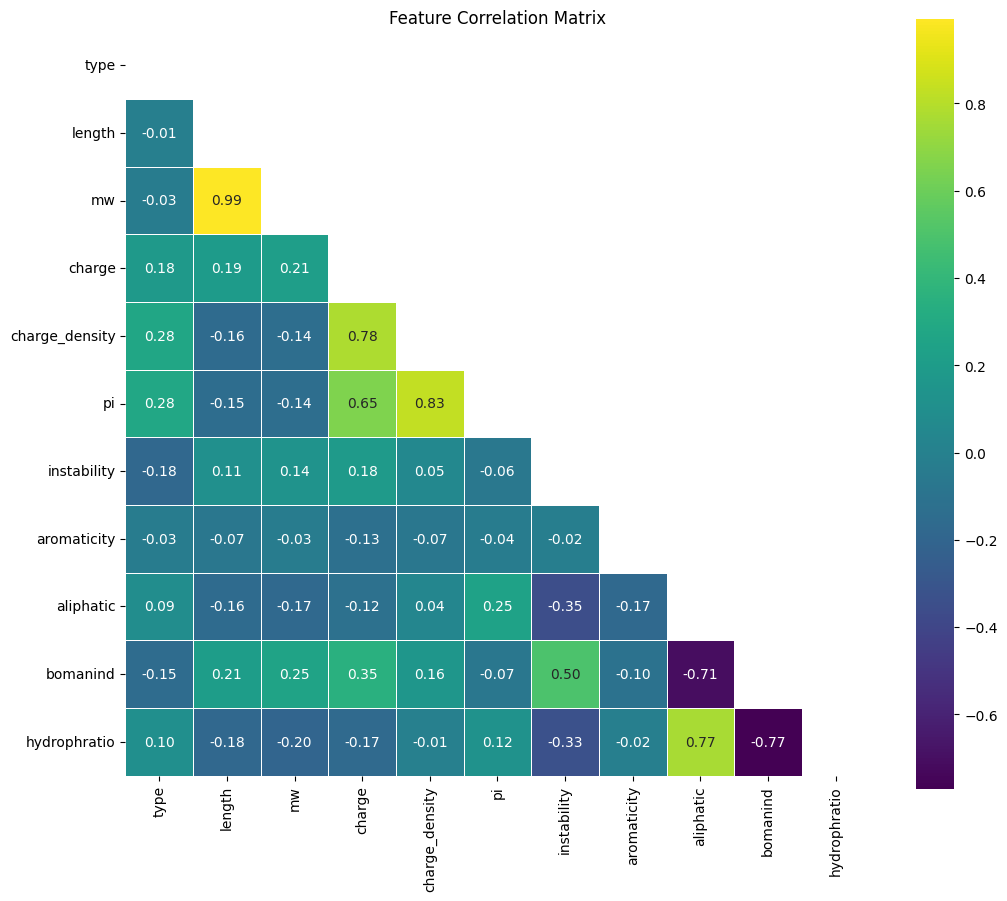

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_numeric = df.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='viridis', 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5
)
plt.title('Feature Correlation Matrix')
plt.show()

Podemos observar alta correlación entre variables como longitud de la secuencia y el peso molecular (0.99), la densidad de la carga y la carga (0.78), el punto isoeléctrico y la densidad de carga (0.83), y su es alifatico o hidrofobico (0.77).
Por otro lado, las correlaciones inversas más altas son entre el índice de Boman y si es alifatico (-0.71), y el índice de Boman y la hidrofobicidad (-0.77).

### **Normalidad**

In [20]:
# Se le hace un test de normalidad a cada variable

import pandas as pd
from scipy import stats

numeric_cols = df.drop(columns=['id', 'sequence', 'type']).apply(pd.to_numeric)

results = []
for col in numeric_cols.columns:
    stat, p_value = stats.shapiro(numeric_cols[col].dropna())
    results.append({
        'Feature': col,
        'Statistic': stat,
        'p-value': p_value,
        'Is_Normal': p_value > 0.05
    })

normality_results = pd.DataFrame(results)
print(normality_results)

          Feature  Statistic       p-value  Is_Normal
0          length   0.761690  5.390253e-71      False
1              mw   0.763996  8.526360e-71      False
2          charge   0.895538  4.001791e-55      False
3  charge_density   0.978346  1.482469e-30      False
4              pi   0.952044  4.935569e-42      False
5     instability   0.872283  8.403256e-59      False
6     aromaticity   0.930245  4.185107e-48      False
7       aliphatic   0.984758  4.284664e-26      False
8        bomanind   0.975420  2.943541e-32      False
9    hydrophratio   0.995400  1.146088e-13      False


c:\Users\Jazmin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6612.
  res = hypotest_fun_out(*samples, **kwds)


Como se rechaza la hipotesis de que las variables tienen distribución normal, se descarta el uso del modelo Gaussian Naive Bayes.

### **Información mutua**

Se calculó la información mutua de las variables, con la fórmula:
$$H(X, Y) = \sum_{X} \sum_{Y} P(X, Y) \log_2 \left[ P(X, Y) / P(X)P(Y) \right]$$

**Es cero cuando dos variables son independientes**

In [21]:
import numpy as np
import pandas as pd

def calculate_mi(x, y, bins=10):
    c_xy, _, _ = np.histogram2d(x, y, bins=bins)
    p_xy = c_xy / np.sum(c_xy)
    
    p_x = np.sum(p_xy, axis=1)
    p_y = np.sum(p_xy, axis=0)
    p_x_p_y = p_x[:, None] * p_y[None, :]
    
    mask = p_xy > 0
    return np.sum(p_xy[mask] * np.log2(p_xy[mask] / p_x_p_y[mask]))

df_numeric = df.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
mutual_information = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns, dtype=float)

for col1 in df_numeric.columns:
    for col2 in df_numeric.columns:
        mutual_information.loc[col1, col2] = calculate_mi(df_numeric[col1], df_numeric[col2])

In [22]:
mutual_information

,type,length,mw,charge,charge_density,pi,instability,aromaticity,aliphatic,bomanind,hydrophratio
type,1.000000,0.000297,0.000926,0.085854,0.112713,0.075967,0.024428,0.002458,0.009304,0.018417,0.011449
length,0.000297,2.057701,1.484746,0.081537,0.057497,0.115877,0.056060,0.038839,0.127167,0.112729,0.127361
mw,0.000926,1.484746,2.014009,0.097420,0.047446,0.116478,0.065644,0.032328,0.135059,0.130639,0.127928
charge,0.085854,0.081537,0.097420,1.240698,0.530129,0.713056,0.072617,0.024686,0.070649,0.148455,0.082637
charge_density,0.112713,0.057497,0.047446,0.530129,1.807256,0.754639,0.073468,0.024025,0.047686,0.145214,0.060441
pi,0.075967,0.115877,0.116478,0.713056,0.754639,3.017964,0.066807,0.031822,0.164826,0.157919,0.082642
instability,0.024428,0.056060,0.065644,0.072617,0.073468,0.066807,1.642443,0.015346,0.103549,0.155564,0.107966
aromaticity,0.002458,0.038839,0.032328,0.024686,0.024025,0.031822,0.015346,1.904495,0.036678,0.024637,0.036560
aliphatic,0.009304,0.127167,0.135059,0.070649,0.047686,0.164826,0.103549,0.036678,2.614065,0.521186,0.629987
bomanind,0.018417,0.112729,0.130639,0.148455,0.145214,0.157919,0.155564,0.024637,0.521186,2.101734,0.628186


### **Transformación de variables** 



Con base en el análisis de correlación, se identificaron **tres grupos con alta dependencia condicional** que violan el supuesto de independencia del NBC. Siguiendo el enfoque SNBC, cuando dos atributos no son independientes dado la clase, se debe **eliminar uno o fusionarlos**.

1.1 Eliminación: `length` 

Debido a que `length` y `mw` tienen correlación de **r = 0.99**, se decidió eliminar length.

1.2 Fusión: `charge`, `charge_density` y `pi`

Correlaciones altas entre sí (r entre 0.78 y 0.83). Las tres tienen información mutua >0 con la actividad microbiana (type) (MI = 0.085, 0.112 y 0.075), por lo que no se elimina ninguna. **Se fusionan en `charge_pi_density`** (media de sus z-scores).

1.3 Fusión: `aliphatic`, `bomanind` y `hydrophratio`

Correlaciones cruzadas de |r| entre 0.71 y 0.77 dentro de cada clase. Describen propiedades relacionadas con hidrofobicidad y estabilidad. **Se fusionan en `hydrophobic_profile`** (media de sus z-scores).

Los atributos `instability` y `aromaticity` **permanecen sin cambios**.

In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")

# Paso 1: Eliminar length 
df_clean = df.drop(columns=["length"])

# Paso 2: Fusionar charge + charge_density + pi
for col in ["charge", "charge_density", "pi"]:
    df_clean[col + "_z"] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

df_clean["charge_pi_density"] = (
    df_clean["charge_z"] + df_clean["charge_density_z"] + df_clean["pi_z"]
) / 3

df_clean = df_clean.drop(columns=[
    "charge", "charge_density", "pi",
    "charge_z", "charge_density_z", "pi_z"
])

# Paso 3: Fusionar aliphatic + bomanind + hydrophratio
for col in ["aliphatic", "bomanind", "hydrophratio"]:
    df_clean[col + "_z"] = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()

df_clean["hydrophobic_profile"] = (
    df_clean["aliphatic_z"] + df_clean["bomanind_z"] + df_clean["hydrophratio_z"]
) / 3

df_clean = df_clean.drop(columns=[
    "aliphatic", "bomanind", "hydrophratio",
    "aliphatic_z", "bomanind_z", "hydrophratio_z"
])

print("Variables finales:", list(df_clean.columns))
df_clean.head(3)

Variables finales: ['id', 'sequence', 'type', 'mw', 'instability', 'aromaticity', 'charge_pi_density', 'hydrophobic_profile']


,id,sequence,type,mw,instability,aromaticity,charge_pi_density,hydrophobic_profile
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,3180.71,7.272727,0.030303,0.262591,0.131165
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,3877.48,84.155882,0.176471,0.447128,-0.874407
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,5947.71,57.074074,0.111111,-0.386263,-0.537667


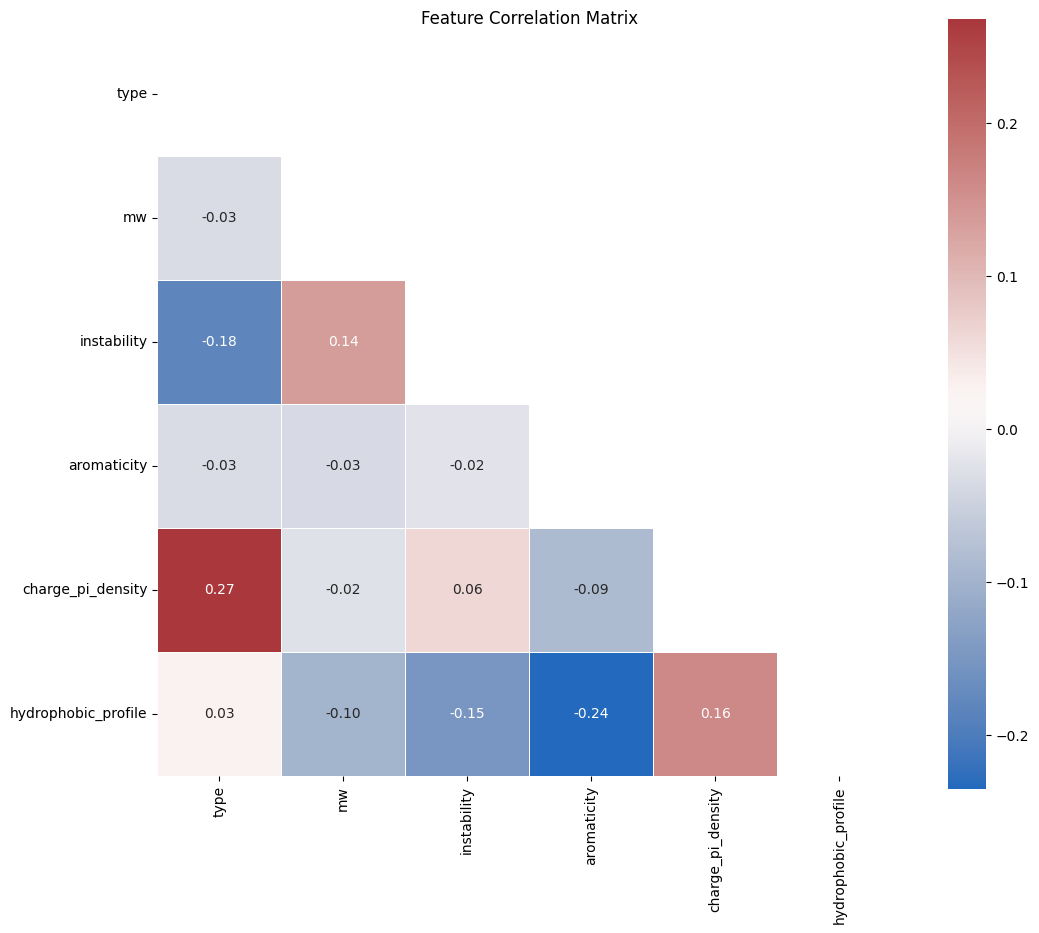

In [24]:
df_numeric = df_clean.drop(columns=['id', 'sequence']).apply(pd.to_numeric)
corr_matrix = df_numeric.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='vlag', 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5
)
plt.title('Feature Correlation Matrix')
plt.show()

## **Representación del modelo**

Este ejercicio tiene por objetivo realizar una clasificación binaria de los péptidos, en si son antimicrobianos o si no lo son. Por lo tanto, los modelos Dinámicos y Temporales, de Clasificación Jerárquica y Multidimensionales y Multietiqueta quedan descartados.
Para nuestro próposito podrían servirnos los siguientes:
- Clasificador Bayesiano Ingenuo (NBC): El cual asume independencia condicional entre todos los atributos dada la clase
- Gaussian Naive Bayes: Los atributos siguen una distribución gaussiana
- TAN (Tree Augmented Bayesian Classifier): Incorpora dependencias entre atributos formando una estructura de árbol dirigido entre ellos
- BAN (Bayesian Network augmented Bayesian Classifier): Relaja la restricción de árbol del TAN, permitiendo que los atributos formen un grafo acíclico dirigido (DAG)
- Clasificadores Bayesianos Semi-ingenuos (SNBC): Buscan mejorar el NBC eliminando atributos irrelevantes o uniendo atributos dependientes para mantener la eficiencia


### **Modelo elegido: SNBC**

Un NBC asume que todos los atributos que se usan para predecir algo son completamente independientes entre sí. Por otro lado, el SNBC es una versión mejorada que soluciona este problema. Su objetivo principal es mantener la simplicidad y rapidez del modelo original, pero mejorando su precisión al eliminar o combinar aquellos atributos que sí dependen unos de otros. Como nosotros eliminamos y combinamos variables con lo que se obtuvieron nuevas variables con muy poca correlación, se decidió elegir este modelo. Además, así evitamos un modelo con complejidad innecesaria como un BAN o Tan y priorizamos el endentimiento del modelo.

## **Discretización de los datos**

Como se está usando el modelo SNBC, implicitamente uno de nuestros objetivos es mantener la simpleza del modelo por lo que se decidió utilizar discretización no supervizada.
Habrá $\sqrt{N}$ intervalos con $\sqrt{N}$ instancias cada uno. 

In [25]:
## **Normalización de los datos**

import pandas as pd
import numpy as np

def apply_pkid(df, continuous_columns):
    n = len(df)
    k = int(np.floor(np.sqrt(n)))
    
    df_discrete = df.copy()
    
    for col in continuous_columns:
        df_discrete[col] = pd.qcut(df_discrete[col], q=k, duplicates='drop')
        
    return df_discrete

continuous_features = [
    'mw', 
    'instability', 
    'aromaticity', 
    'charge_pi_density', 
    'hydrophobic_profile'
]

df_discretized = apply_pkid(df_clean, continuous_features)

In [28]:
df_discretized.head(3)

,id,sequence,type,mw,instability,aromaticity,charge_pi_density,hydrophobic_profile
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,"(3154.788, 3201.07]","(6.395, 7.687]","(0.0294, 0.0312]","(0.26, 0.284]","(0.125, 0.136]"
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,"(3824.507, 3881.507]","(79.52, 84.707]","(0.167, 0.176]","(0.43, 0.449]","(-1.023, -0.842]"
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,"(5896.809, 6286.902]","(56.512, 58.105]","(0.108, 0.111]","(-0.39, -0.365]","(-0.562, -0.525]"


In [30]:
# Comprobación del número de instancias e intervalos
import pandas as pd
import numpy as np

def visualize_pkid_distribution(df, continuous_columns):
    n = len(df)
    k = int(np.round(np.sqrt(n)))
    
    print(f"Total Instances: {n}")
    print(f"Expected Intervals: {k}")
    print(f"Expected Instances per Interval: {np.sqrt(n):.2f}\n")
    print("-" * 50)
    
    results = {}
    
    for col in continuous_columns:
        try:
            discretized_col = pd.qcut(df[col], q=k, duplicates='drop')
            
            counts = discretized_col.value_counts().sort_index().reset_index()
            counts.columns = ['Interval', 'Count']
            
            print(f"Feature: {col}")
            print(counts.to_string(index=False))
            print("-" * 50)
            
            results[col] = counts
            
        except ValueError as e:
            print(f"Feature: {col} - Error: {e}")
            print("-" * 50)
            
    return results

continuous_features = [
    'mw', 
    'instability', 
    'aromaticity', 
    'charge_pi_density', 
    'hydrophobic_profile'
]

distributions = visualize_pkid_distribution(df_clean, continuous_features)

Total Instances: 6612
Expected Intervals: 81
Expected Instances per Interval: 81.31

--------------------------------------------------
Feature: mw
              Interval  Count
    (259.309, 810.242]     82
   (810.242, 1047.412]     82
  (1047.412, 1232.291]     81
  (1232.291, 1351.619]     82
  (1351.619, 1400.867]     82
  (1400.867, 1450.657]     81
  (1450.657, 1489.709]     82
  (1489.709, 1540.927]     81
  (1540.927, 1588.554]     82
   (1588.554, 1628.96]     82
   (1628.96, 1684.589]     81
  (1684.589, 1752.422]     82
  (1752.422, 1810.327]     82
  (1810.327, 1875.797]     81
    (1875.797, 1935.3]     82
    (1935.3, 1974.339]     81
  (1974.339, 2016.963]     82
  (2016.963, 2061.369]     82
  (2061.369, 2106.011]     81
  (2106.011, 2158.973]     82
  (2158.973, 2207.539]     81
  (2207.539, 2263.633]     82
   (2263.633, 2318.99]     82
   (2318.99, 2378.599]     81
  (2378.599, 2418.895]     82
  (2418.895, 2467.796]     82
  (2467.796, 2518.873]     81
    (2518.87

Se puede observar que todos los intervalos quedaron bien, excepto los de aromaticidad, que concentran demasiados valores en el primer intervalo. Esto pasa porque la aromaticidad depende exclusivamente de la presencia de aminoácidos específicos con anillos aromáticos (como fenilalanina, tirosina o triptófano) y es muy probable que una gran proporción de los péptidos analizados carezcan por completo de estos residuos en su secuencia, resultando en un valor exacto de cero que el algoritmo no puede subdividir matemáticamente. Por lo tanto, para esta variable se decidió hacer otro tipo de discretización; una discretización híbrida, la cual consiste en aislar el valor dominante (cero absoluto) en una categoría independiente y aplicar el método de intervalos proporcionales (PKID) de manera exclusiva al subconjunto de péptidos que sí presentan una aromaticidad mayor a cero. Sin embargo, nos volvimos a encontrar con el mismo problema de que los datos no quedaban bien distribuidos en los bins, por lo cual decidimos calcular la mediana y utilizarla como umbral para aplicar una discretización binaria. De esta forma, los péptidos con una aromaticidad inferior a la mediana se asignaron a una categoría (0), mientras que aquellos con un valor igual o superior se agruparon en la otra (1). Esta decisión se fundamenta en que la mediana es una medida de posición central altamente robusta frente a distribuciones fuertemente sesgadas o asimétricas. Al utilizarla como punto de corte, se garantiza matemáticamente una partición perfectamente balanceada, dividiendo el conjunto de datos en dos mitades con la misma cantidad de instancias y resolviendo así la inestabilidad de las probabilidades en el modelo.

In [36]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np

def apply_pkid2(df, continuous_columns):
    df_out = df.copy()
    n_total = len(df_out)
    
    for col in continuous_columns:
        if col == 'aromaticity':
            median_val = df_out[col].median()
            
            df_out[col] = np.where(df_out[col] >= median_val, '1', '0')
            

            
        else:
            k = int(np.round(np.sqrt(n_total)))
            
            df_out[col] = pd.qcut(df_out[col], q=k, duplicates='drop').astype(str)
            
        counts = df_out[col].value_counts().sort_index().reset_index()
        counts.columns = ['Interval', 'Count']

    return df_out

continuous_features = [
    'mw', 
    'instability', 
    'aromaticity', 
    'charge_pi_density', 
    'hydrophobic_profile'
]

df_final = apply_pkid2(df_clean, continuous_features)

In [33]:
df_final.head(3)

,id,sequence,type,mw,instability,aromaticity,charge_pi_density,hydrophobic_profile
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,"(3154.788, 3201.07]","(6.395, 7.687]","(0.0294, 0.0303]","(0.26, 0.284]","(0.125, 0.136]"
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,"(3824.507, 3881.507]","(79.52, 84.707]","(0.172, 0.182]","(0.43, 0.449]","(-1.023, -0.842]"
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,"(5896.809, 6286.902]","(56.512, 58.105]","(0.109, 0.111]","(-0.39, -0.365]","(-0.562, -0.525]"


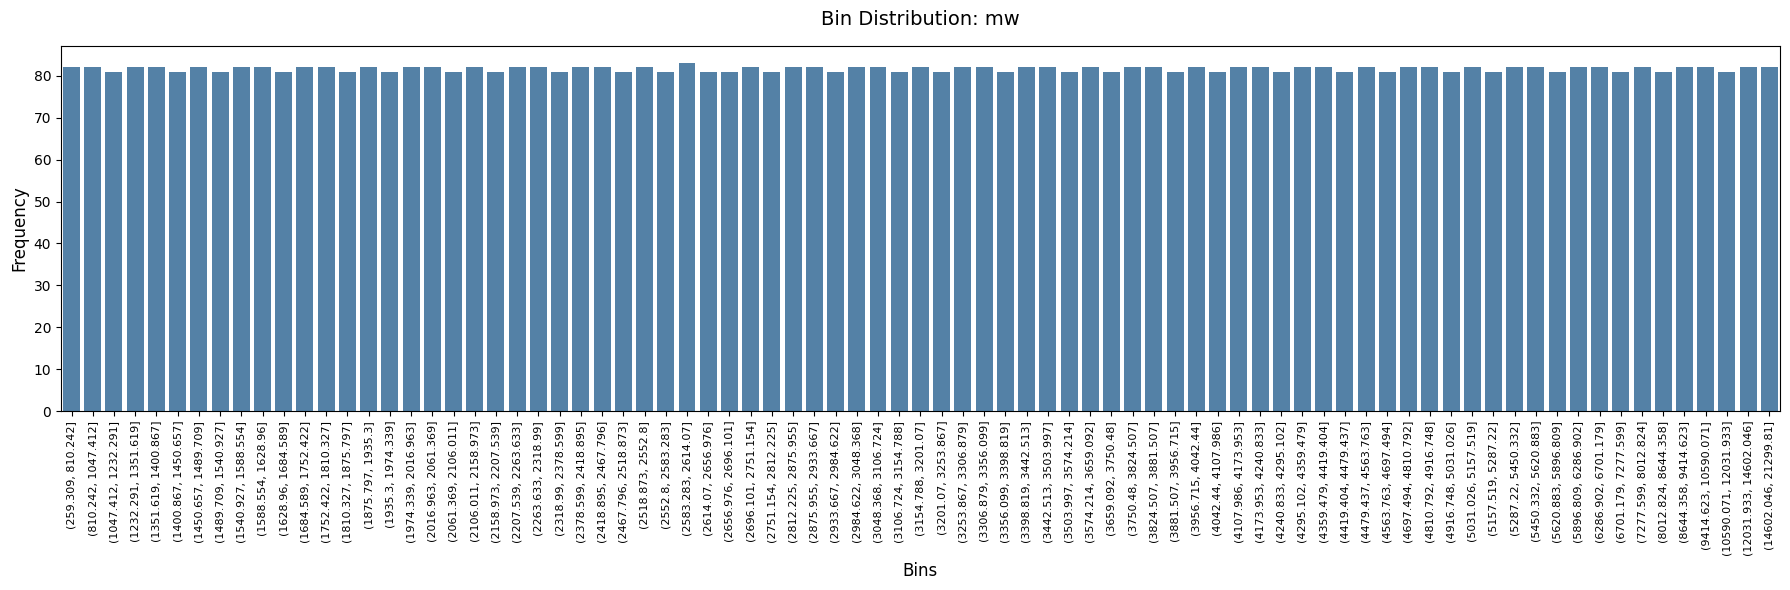

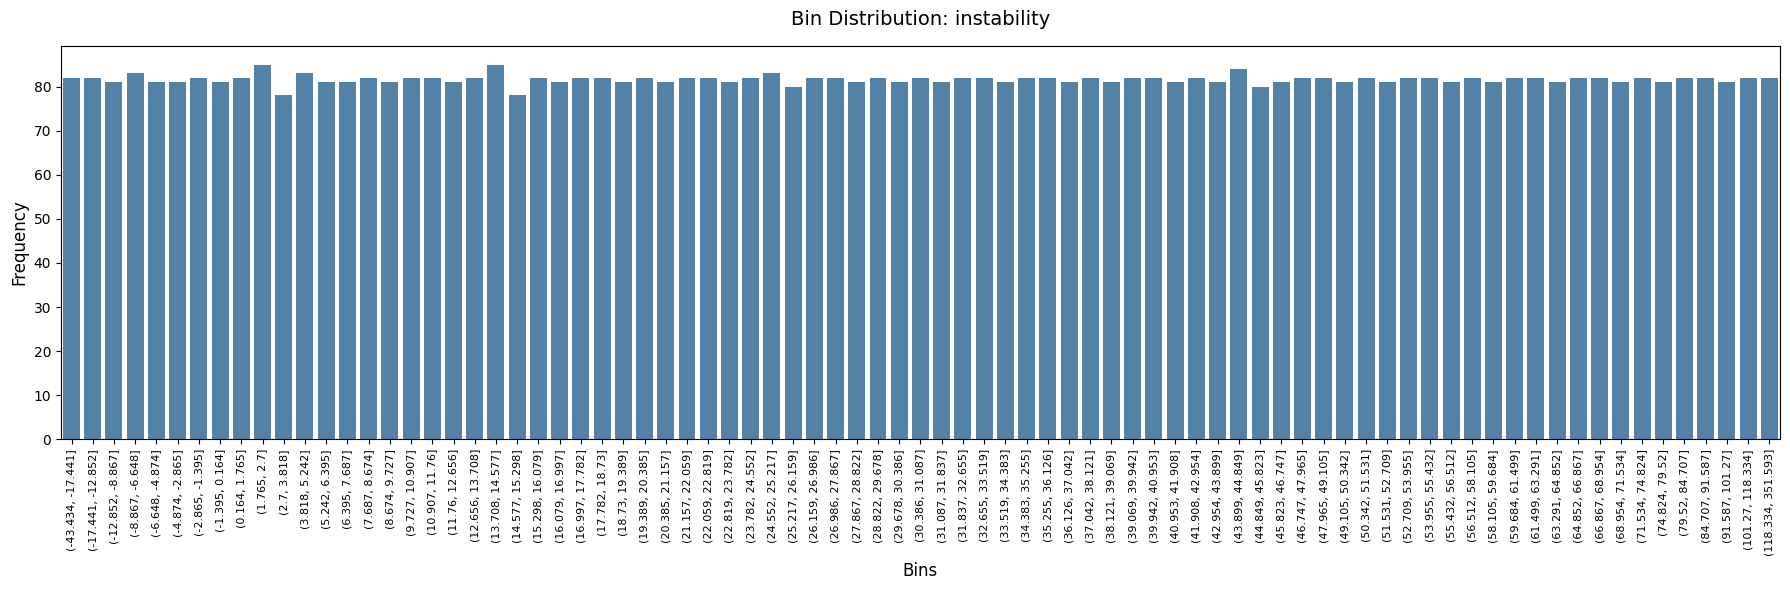

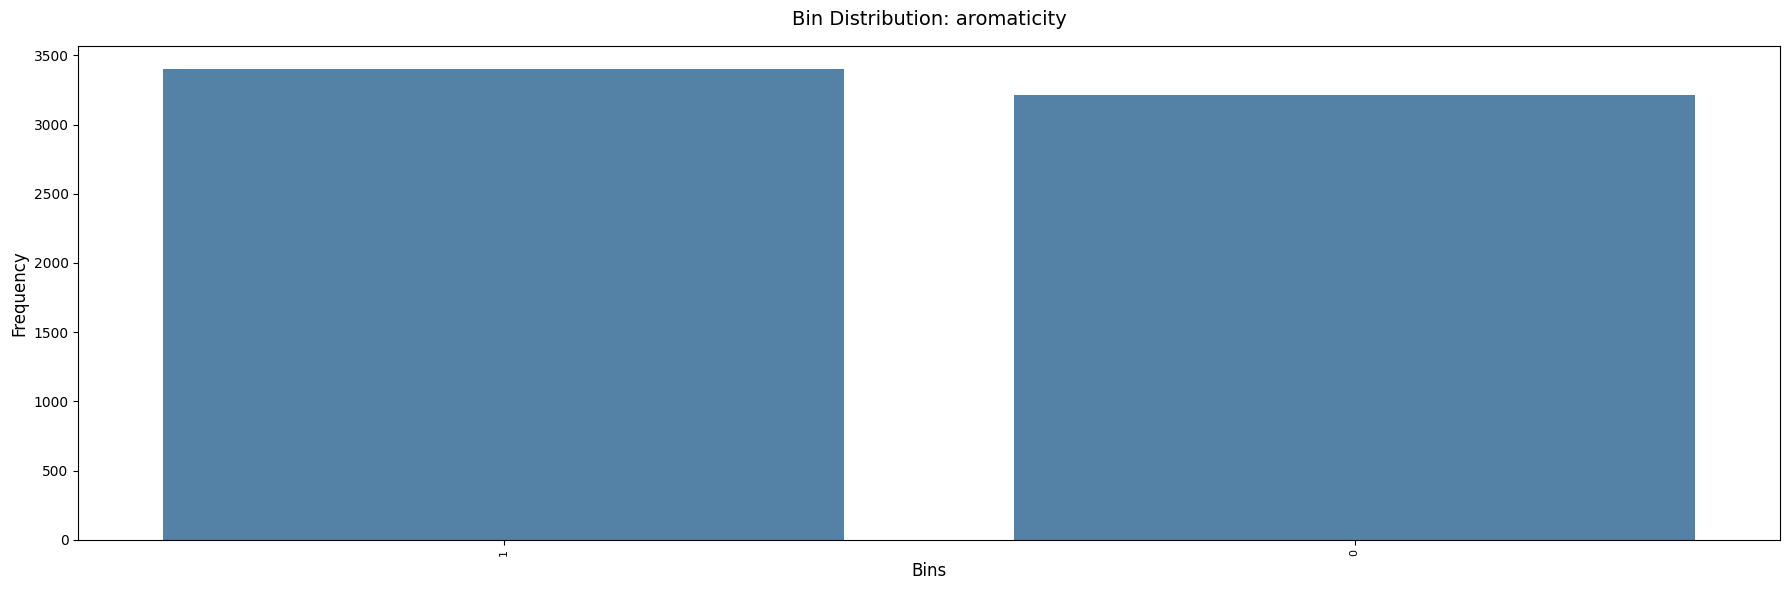

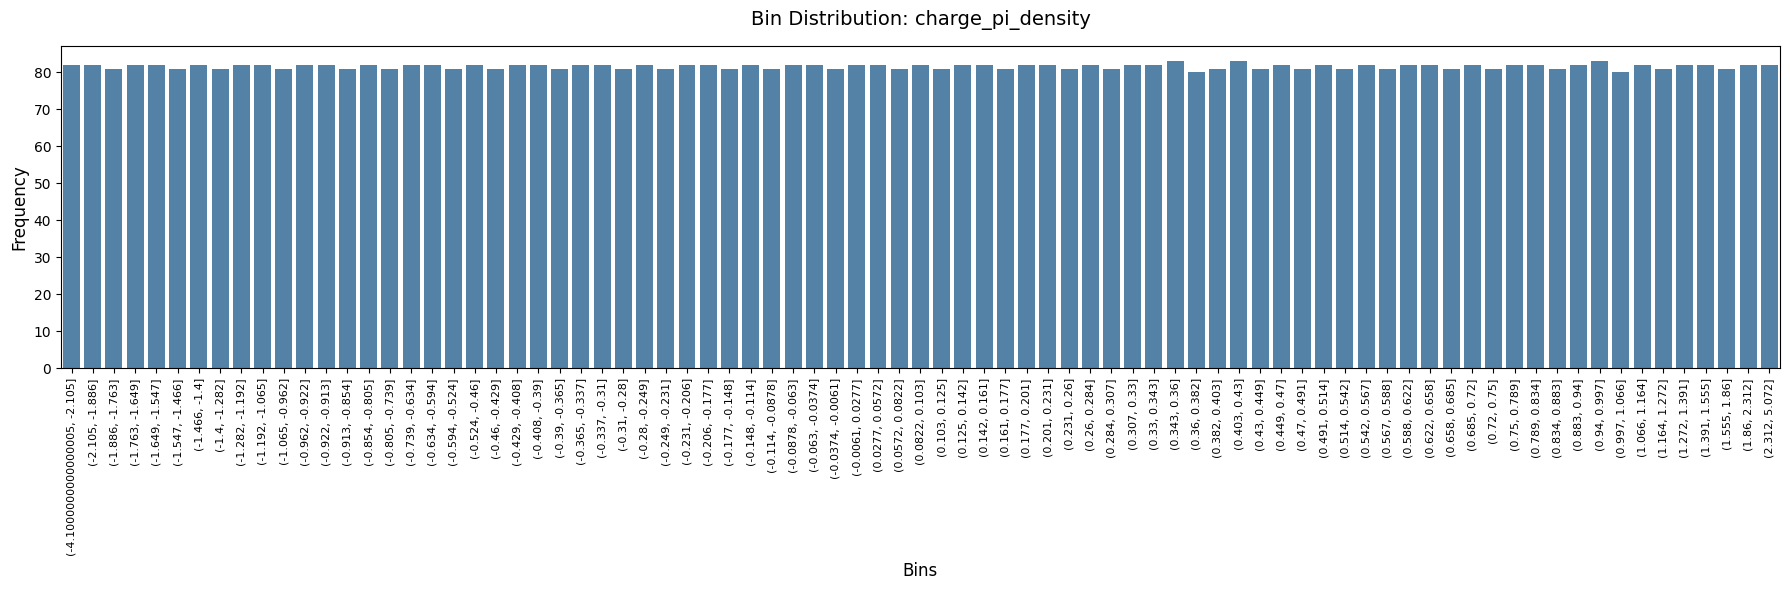

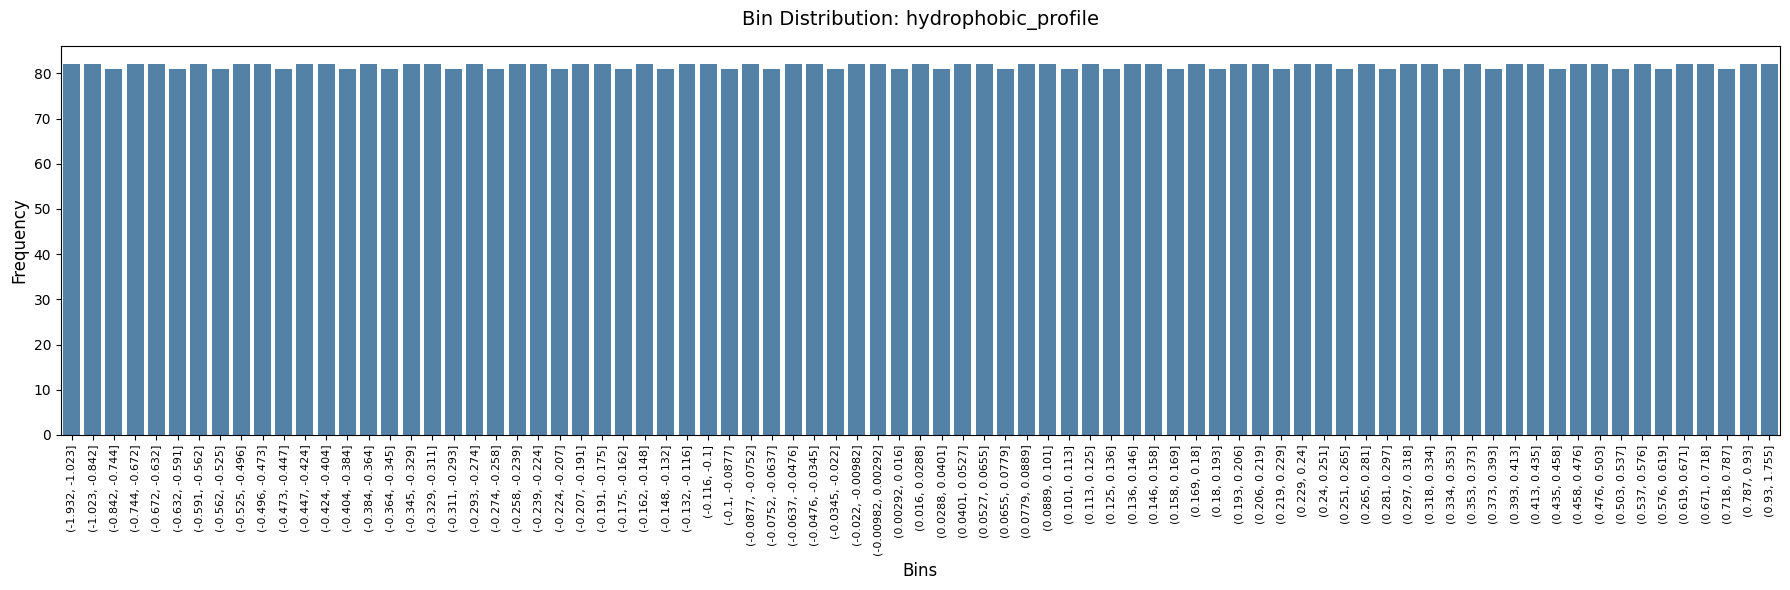

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

def plot_discretization_bins(df, columns):
    for col in columns:
        counts = df[col].value_counts()
        
        def get_sort_value(interval_str):
            if interval_str == 'Zero_Aromaticity':
                return -float('inf')
            match = re.search(r'\(([-+]?[0-9]*\.?[0-9]+)', str(interval_str))
            if match:
                return float(match.group(1))
            return float('inf')
            
        sorted_indices = sorted(counts.index, key=get_sort_value)
        counts = counts.reindex(sorted_indices)
        
        plt.figure(figsize=(18, 6))
        sns.barplot(x=counts.index, y=counts.values, color='steelblue')
        
        plt.title(f'Bin Distribution: {col}', fontsize=14, pad=15)
        plt.xlabel('Bins', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.xticks(rotation=90, fontsize=8)
        
        plt.tight_layout()
        plt.show()

continuous_features = [
    'mw', 
    'instability', 
    'aromaticity', 
    'charge_pi_density', 
    'hydrophobic_profile'
]

plot_discretization_bins(df_final, continuous_features)

## **Formalización matemática del modelo elegido (SNBC)**


**Variables**

- Variable de clase: $C \in \{0, 1\}$, donde $C=1$ es "es péptido antimicrobiano" y $C=0$ es "no es péptido antimicrobiano".
- Vector de atributos:
$$\mathbf{A} = (A_1,\dots,A_5) = (\text{mw},\ \text{instability},\ \text{aromaticity},\ \text{charge\_pi\_density},\ \text{hydrophobic\_profile})$$
  Cada $A_j$ es continuo y se discretiza en $b$ bins antes de estimar sus probabilidades.

**Supuesto de independencia**

$$P(A_i \mid A_j, C) = P(A_i \mid C), \qquad \forall i \neq j$$

Este es el supuesto que falla para los 10 descriptores originales; por eso no se modelan directamente, y en su lugar se aplica el procedimiento de fusión/eliminación para obtener el conjunto reducido $\mathbf{A}$, en el que la dependencia condicional remanente es aproximadamente nula. Por lo tanto, `SNBayesianClassifier` es, formalmente, **un NBC aplicado sobre atributos transformados**, no sobre los atributos originales.

**Modelo generativo**

$$P(C=c \mid \mathbf{A}) \;\propto\; P(C=c) \prod_{j=1}^{5} P(A_j \mid C=c)$$

**Parámetros**

- Prior $P(C=c)$ 
- Para cada atributo $A_j$ y cada clase $c$, una CPT con $b$ entradas, estimada con suavizado de Laplace:
$$P(A_j = k \mid C = c) = \frac{N_{jkc} + \alpha}{N_c + \alpha b}$$
  con $N_{jkc}$ el número de instancias de clase $c$ cuyo atributo $j$ cae en el bin $k$, y $N_c$ el total de instancias de clase $c$.



**Vínculo con el problema:** Cada péptido se reduce a un punto en este espacio de 5 descriptores fisicoquímicos; el modelo aprende, para cada clase, qué combinaciones de bins son más probables, y clasifica un péptido nuevo según qué clase asigna mayor probabilidad posterior a sus valores observados.

In [26]:
df_clean.head(4)

,id,sequence,type,mw,instability,aromaticity,charge_pi_density,hydrophobic_profile
0,AP00001,GLWSKIKEVGKEAAKAAAKAAGKAALGAVSEAV,1,3180.71,7.272727,0.030303,0.262591,0.131165
1,AP00002,YVPLPNVPQPGRRPFPTFPGQGPFNPKIKWPQGY,1,3877.48,84.155882,0.176471,0.447128,-0.874407
2,AP00003,DGVKLCDVPSGTWSGHCGSSSKCSQQCKDREHFAYGGACHYQFPSV...,1,5947.71,57.074074,0.111111,-0.386263,-0.537667
3,AP00004,NLCERASLTWTGNCGNTGHCDTQCRNWESAKHGACHKRGNWKCFCYFDC,1,5613.26,16.722449,0.122449,-0.533268,-0.498872


Como primer paso se debe de hacer la discretización de las variables continuas. Vamos a hacerlo de forma no supervizada, creando $\sqrt{N}$ intervalos con $\sqrt{N}$ instancias cada uno.

In [27]:
class SNBayesianClassifier:

    def __init__(self, n_bins=5, laplace_alpha=1):
        # Number of intervals used to discretize continuous features
        self.n_bins = n_bins

        # Laplace smoothing parameter applied to conditional probabilities
        self.alpha = laplace_alpha

        # Set of class labels observed during training
        self.classes_ = None

        # Prior probabilities P(c)
        self.prior_ = {}

        # Conditional probability tables (CPTs) storing P(A_j = k | c)
        self.cpt_ = {}

        # Bin boundaries used for feature discretization
        self.bin_edges_ = {}

    # ---------- Feature Discretization -----------------------------------
    def _compute_bins(self, X):

        edges = {}

        for col in X.columns:
            quantiles = np.linspace(0, 100, self.n_bins + 1)

            # Generate bin boundaries from feature quantiles
            edges[col] = np.unique(np.percentile(X[col], quantiles))

            # Handle degenerate cases where all values are identical
            if len(edges[col]) < 2:
                edges[col] = np.array(
                    [X[col].min() - 1e-9, X[col].max() + 1e-9]
                )

        return edges

    def _discretize(self, X):

        X_disc = pd.DataFrame(index=X.index)

        for col in X.columns:
            edges = self.bin_edges_[col]

            # Assign each value to its corresponding interval
            X_disc[col] = (
                np.digitize(X[col], bins=edges[:-1], right=False) - 1
            )

            # Ensure indices remain within the valid bin range
            X_disc[col] = X_disc[col].clip(0, len(edges) - 2)

        return X_disc

    # ---------- Model Training -------------------------------------------
    def fit(self, X, y):

        X = pd.DataFrame(X).reset_index(drop=True)
        y = np.array(y)

        self.classes_ = np.unique(y)
        N = len(y)

        # Estimate class prior probabilities P(c)
        for c in self.classes_:
            self.prior_[c] = np.sum(y == c) / N

        # Learn discretization boundaries from training data
        self.bin_edges_ = self._compute_bins(X)
        X_disc = self._discretize(X)

        # Estimate conditional probabilities P(A_j = k | c)
        # using Laplace smoothing
        for col in X_disc.columns:
            n_vals = self.n_bins
            self.cpt_[col] = {}

            for c in self.classes_:
                mask = y == c
                counts = np.zeros(n_vals)

                # Count occurrences of each discretized value
                for k in range(n_vals):
                    counts[k] = np.sum(X_disc.loc[mask, col] == k)

                # Apply Laplace correction to avoid zero probabilities
                prob = (
                    counts + self.alpha
                ) / (
                    counts.sum() + self.alpha * n_vals
                )

                self.cpt_[col][c] = prob

        return self

    # ---------- Probabilistic Inference ----------------------------------
    def predict_proba(self, X):

        X = pd.DataFrame(X).reset_index(drop=True)
        X_disc = self._discretize(X)

        proba = np.zeros((len(X), len(self.classes_)))

        for idx_c, c in enumerate(self.classes_):

            # Start with the log prior probability
            log_prob = np.log(self.prior_[c])

            # Accumulate log conditional probabilities
            for col in X_disc.columns:
                k_vals = X_disc[col].values.astype(int)
                k_vals = np.clip(k_vals, 0, self.n_bins - 1)

                log_prob = (
                    log_prob +
                    np.log(self.cpt_[col][c][k_vals])
                )

            proba[:, idx_c] = log_prob

        # Convert log-scores into normalized posterior probabilities
        # using the log-sum-exp stabilization strategy
        proba = proba - proba.max(axis=1, keepdims=True)
        proba = np.exp(proba)
        proba = proba / proba.sum(axis=1, keepdims=True)

        return proba

    def predict(self, X):
        proba = self.predict_proba(X)

        # Select the class with maximum posterior probability
        return self.classes_[np.argmax(proba, axis=1)]